# Overview (Candidate)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# # adjust pandas display options to max
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# # adjust pandas display options to ensure full display of content
# pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    3.0.2
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_parquet("../Data/CAN_Heart_Data.parquet")
# display
df.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Weight_kg_Registrsation_CAN,Height_cm_Registration_CAN,BMI_Listing_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,...,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,0,DILATED MYOPATHY: IDIOPATHIC,M,A,65.771,173.0,22.0470,US Citizen,CA,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2013,329.0,No,2,2,1,5,Identical
1,0,DILATED MYOPATHY: OTHER SPECIFY,M,O,72.575,185.0,21.1093,US Citizen,TX,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,2592.0,Yes,1,2,2,5,Identical
2,0,DILATED MYOPATHY: ISCHEMIC,M,O,106.000,175.0,34.5096,US Citizen,NY,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2012,2913.0,Yes,0,1,2,3,Identical
3,0,DILATED MYOPATHY: ISCHEMIC,M,A,111.000,178.0,35.0335,US Citizen,NY,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,1225.0,Yes,2,2,2,6,Identical
4,0,DILATED MYOPATHY: IDIOPATHIC,M,A,72.000,172.0,24.3375,US Citizen,NC,ASSOCIATE/BACHELOR DEGREE,...,Orthotopic Bicaval,2013,2012,2785.0,Yes,0,2,2,4,Identical


In [3]:
df.info(max_cols=df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 146 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  30300 non-null  category
 1    WaitListDiagnosisCode_CAN                     30300 non-null  category
 2    Gender_CAN                                    30300 non-null  category
 3    BloodGroup_CAN                                30300 non-null  category
 4    Weight_kg_Registrsation_CAN                   30250 non-null  float64 
 5    Height_cm_Registration_CAN                    30187 non-null  float64 
 6    BMI_Listing_CAN                               30185 non-null  float64 
 7    Citizenship_CAN                               30300 non-null  category
 8    ResidencyStateRegistration_CAN                30300 non-null  category
 9    EducationLevel_CAN                            30

## Gender

In [4]:
# nans
u.any_nans(df)

--- Missing Values Found () (Total Rows: 30,300) ---
                                     Count Percentage
HemodynamicsRegistration_PCW_CAN      2838    9.3663%
HemodynamicsTransplant_PCW_CAN        2226    7.3465%
HemodynamicsRegistration_CO_CAN       1730    5.7096%
HemodynamicsRegistration_PA_MN_CAN    1390    4.5875%
FunctionalStatusTransplant_CAN        1375    4.5380%
HemodynamicsTransplant_CO_CAN         1371    4.5248%
HemodynamicsTransplant_PA_MN_CAN      1184    3.9076%
HemodynamicsRegistration_PA_DIA_CAN   1072    3.5380%
HemodynamicsRegistration_SYS_CAN      1050    3.4653%
FunctionalStatusRegistration_CAN       975    3.2178%
HemodynamicsTransplant_PA_DIA_CAN      885    2.9208%
HemodynamicsTransplant_SYS_CAN         861    2.8416%
TotalBilirubinTransplant_CAN           118    0.3894%
BMI_Listing_CAN                        115    0.3795%
Height_cm_Registration_CAN             113    0.3729%
CreatinineRegistration_CAN             104    0.3432%
CreatinineTransplant_CAN     

In [5]:
df.Gender_CAN.value_counts(dropna=False)

Gender_CAN
M    22236
F     8064
Name: count, dtype: int64

In [6]:
df_m = df[df.Gender_CAN == 'M'].copy()
df_f = df[df.Gender_CAN == 'F'].copy()
#
df_m.shape, df_f.shape

((22236, 146), (8064, 146))

### User Function(s)

In [7]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()



def apply_pca_feature_engineering(data, features, prefix, n_components=0.9, seed=SEED):
    """
    Standardizes features, performs PCA, and appends scores and variance weights.
    
    Args:
        data: Input DataFrame.
        features: List of numeric column names to reduce.
        prefix: String prefix for new columns (e.g., 'hemo_reg').
        n_components: Variance threshold or fixed number of components.
        seed: Random state for reproducibility.
    """
    if not features:
        return data

    # Scale and Transform
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(data[features])
    
    pca = PCA(n_components=n_components, random_state=seed)
    pca_scores = pca.fit_transform(x_scaled)
    
    # Extract Variance Stats
    exp_var = pca.explained_variance_ratio_
    # Weights normalized to the sum of explained variance
    # pc_weights = exp_var / np.sum(exp_var)
    n_pcs = pca.n_components_

    # Create Column Names
    pc_cols = [f'PC{i+1}_{prefix}' for i in range(n_pcs)]
    var_cols = [f'PC{i+1}_{prefix}_var' for i in range(n_pcs)]

    # Build DataFrames for concatenation (Vectorized)
    pca_df = pd.DataFrame(pca_scores, columns=pc_cols, index=data.index)
    
    # Using np.tile is the fastest way to broadcast weights across the index
    var_data = np.tile(exp_var, (len(data), 1))
    # var_data = np.tile(pc_weights, (len(data), 1))
    var_df = pd.DataFrame(var_data, columns=var_cols, index=data.index)

    # Clean and Merge
    # adding new engineered columns in one pass
    df_out = pd.concat([
        data,
        # data.drop(columns=features), # Dropping original features and 
        pca_df, 
        var_df
    ], axis=1)

    print(f"[{prefix}] Retained {n_pcs} components ({exp_var.sum():.2%} variance explained)")
    
    return df_out

## Hemodynamics

### Hemodynamics Registration

#### Male

In [8]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsRegistration', cat=False)
# feature
total_features = features

                                       count       mean        std   min   25%   50%   75%    max
HemodynamicsRegistration_CO_CAN      20986.0   4.424433   1.348750  0.39   3.5   4.3   5.2   15.0
HemodynamicsRegistration_PA_DIA_CAN  21505.0  20.928073   8.782456  0.00  15.0  20.0  27.0   83.0
HemodynamicsRegistration_PA_MN_CAN   21238.0  29.169319  10.317214  0.00  21.0  29.0  36.0   87.0
HemodynamicsRegistration_PCW_CAN     20149.0  19.631446   8.885594  0.00  13.0  20.0  26.0   50.0
HemodynamicsRegistration_SYS_CAN     21523.0  42.791897  14.465021  0.00  32.0  42.0  53.0  123.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        1250
HemodynamicsRegistration_PA_DIA_CAN     731
HemodynamicsRegistration_PA_MN_CAN      998
HemodynamicsRegistration_PCW_CAN       2087
HemodynamicsRegistration_SYS_CAN        713 



Those hemodynamic variables (Cardiac Output, Pulmonary Artery pressures, and Wedge pressure) are notorious for having missing data in donor registries because they require invasive Swan-Ganz catheterization, which isn't performed on every donor.

* CO (Cardiac Output)
* PA_DIA (Pulmonary Artery Diastolic)
* PA_MN (Pulmonary Artery Mean)
* PCW (Pulmonary Capillary Wedge)
* SYS (Systemic Arterial Systolic)

In [9]:
df_m[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.237766,-0.216207,-0.261080,-0.177958
HemodynamicsRegistration_PA_DIA_CAN,-0.237766,1.000000,0.895253,0.822036,0.783360
HemodynamicsRegistration_PA_MN_CAN,-0.216207,0.895253,1.000000,0.838893,0.919842
HemodynamicsRegistration_PCW_CAN,-0.261080,0.822036,0.838893,1.000000,0.763254
HemodynamicsRegistration_SYS_CAN,-0.177958,0.783360,0.919842,0.763254,1.000000


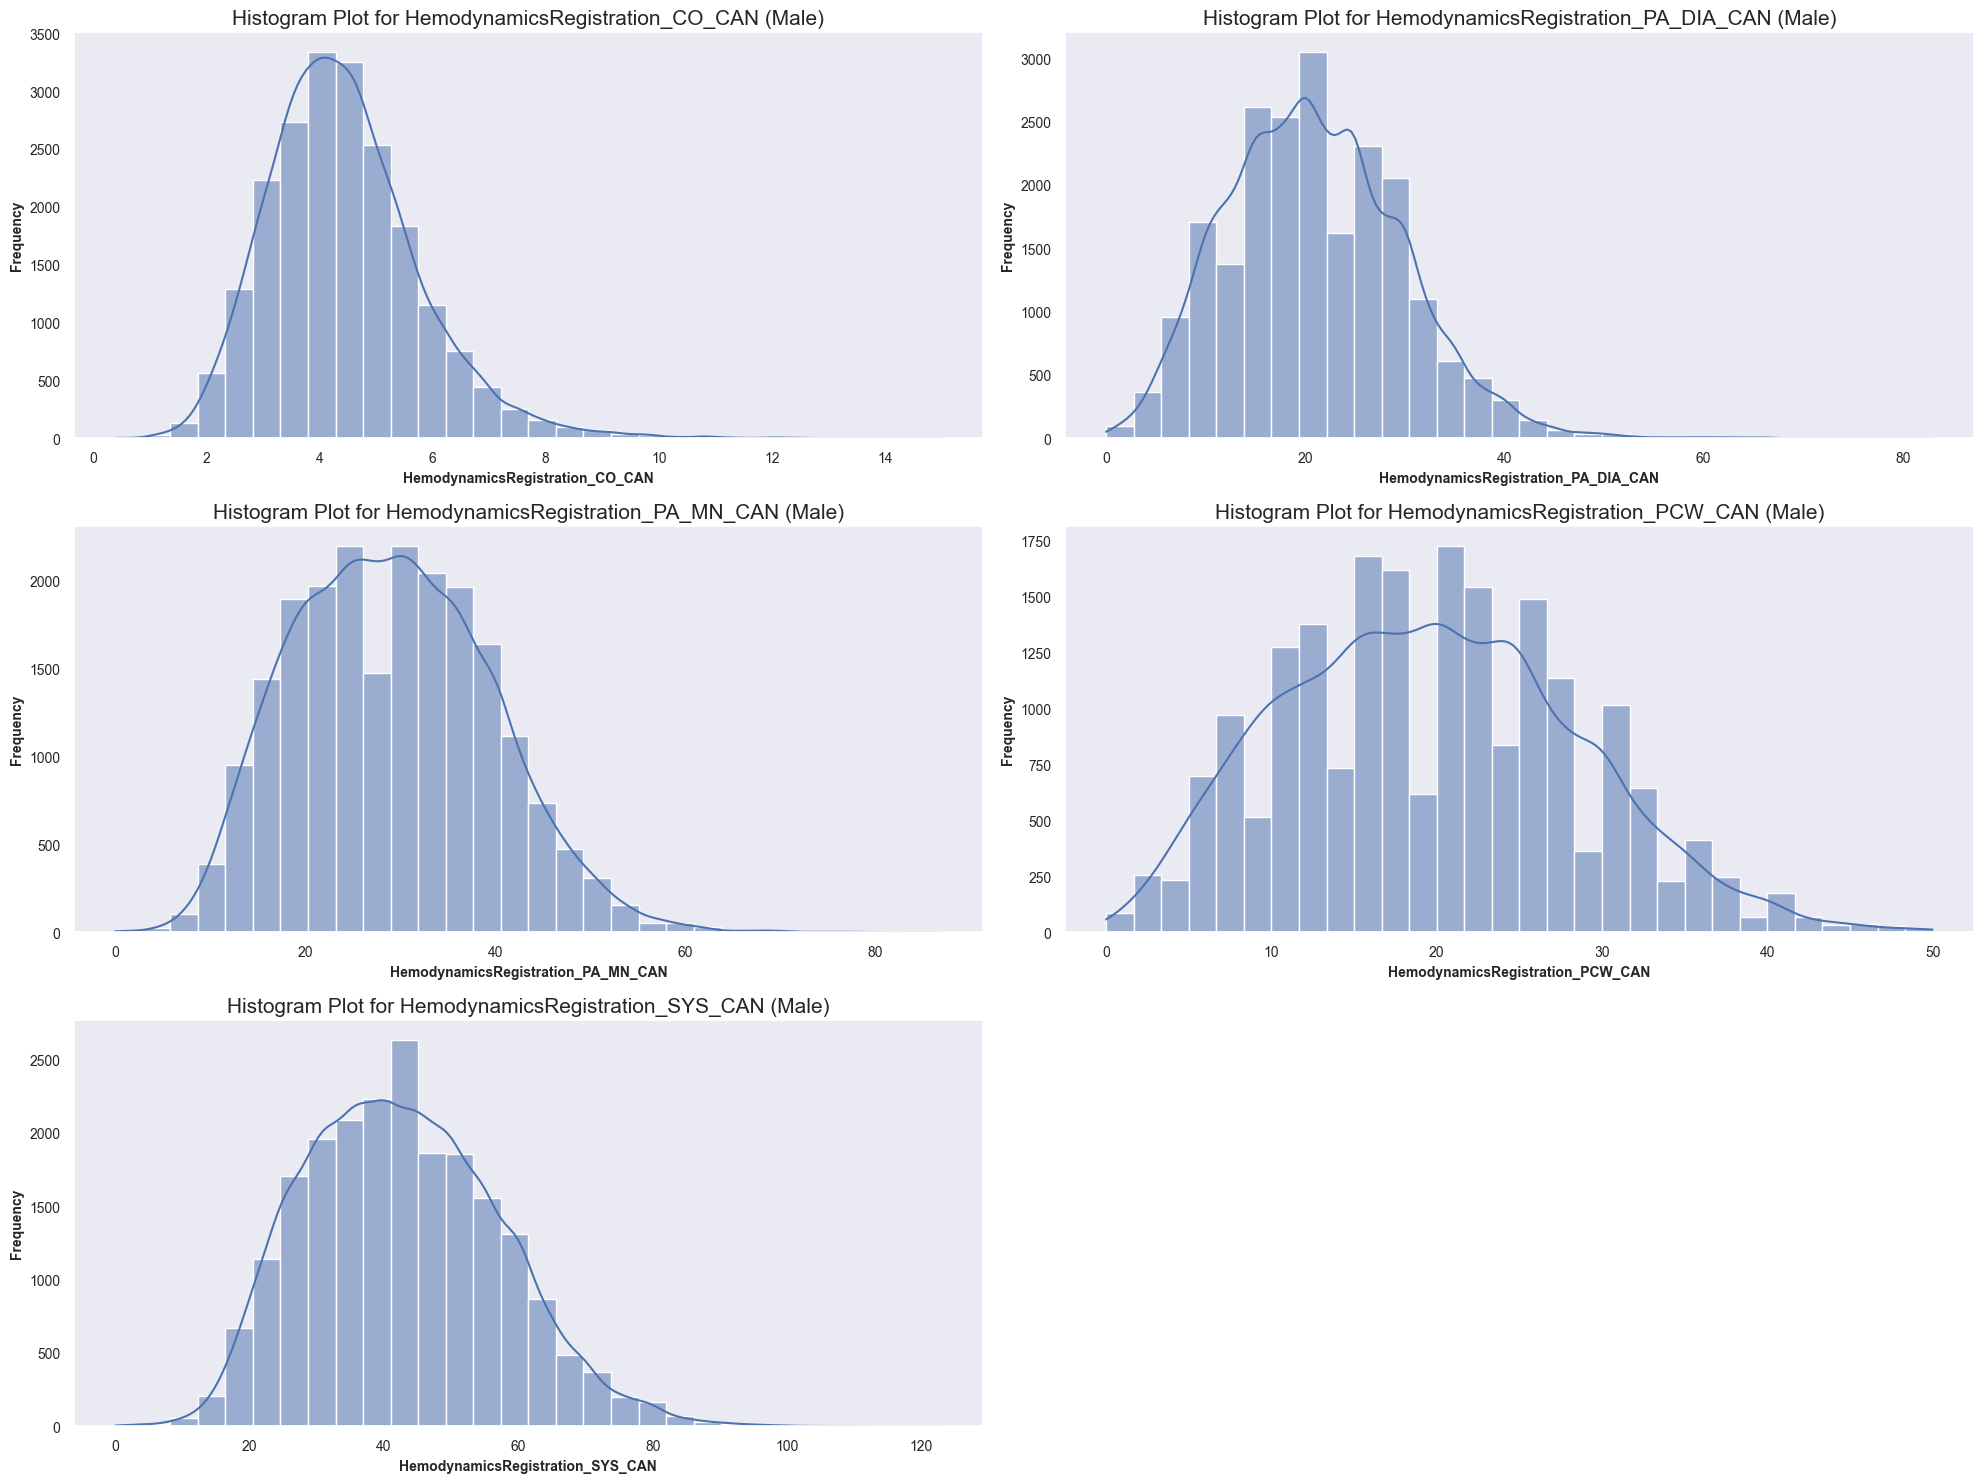

In [10]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [11]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=1,250, Known=20,986)
Mean survival:  (Unknown=1,403.1d, Known=1,438.8d)
Difference:     -35.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3166
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0308 (Negligible)
95% CI:        [-0.0879, 0.0262]
Result: Likely Random Missingness (Effect size not significant)



In [12]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.002, p=0.7435 & Approx. Variance Explained=0.001%
Spearman r=0.000, p=0.9936 & Approx. Variance Explained=0.000%



#### Median Imputation

In [13]:
# Median impute
df_m['HemodynamicsRegistration_CO_CAN'] = df_m['HemodynamicsRegistration_CO_CAN'].fillna(
    df_m['HemodynamicsRegistration_CO_CAN'].median()
)

In [14]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=731, Known=21,505)
Mean survival:  (Unknown=1,325.6d, Known=1,440.5d)
Difference:     -114.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0133
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.0993 (Negligible)
95% CI:        [-0.1731, -0.0256]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Median Imputation

In [15]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_PA_DIA_IsMissing'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_PA_DIA_CAN'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [16]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.037, p=4.331e-08 & Approx. Variance Explained=0.135%
Spearman r=0.033, p=1.07e-06 & Approx. Variance Explained=0.107%



In [17]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=998, Known=21,238)
Mean survival:  (Unknown=1,481.3d, Known=1,434.7d)
Difference:     46.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2519
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0403 (Negligible)
95% CI:        [-0.0232, 0.1038]
Result: Likely Random Missingness (Effect size not significant)



In [18]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_MN_CAN ---
Pearson r=0.046, p=2.065e-11 & Approx. Variance Explained=0.211%
Spearman r=0.041, p=2.321e-09 & Approx. Variance Explained=0.168%



#### Median Imputation

In [19]:
# Median impute
df_m['HemodynamicsRegistration_PA_MN_CAN'] = df_m['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [20]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=2,087, Known=20,149)
Mean survival:  (Unknown=1,442.3d, Known=1,436.2d)
Difference:     6.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.8223
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0053 (Negligible)
95% CI:        [-0.0398, 0.0504]
Result: Likely Random Missingness (Effect size not significant)



In [21]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PCW_CAN ---
Pearson r=0.049, p=5.44e-12 & Approx. Variance Explained=0.236%
Spearman r=0.044, p=4.374e-10 & Approx. Variance Explained=0.193%



#### Median Imputation

In [22]:
# Median impute
df_m['HemodynamicsRegistration_PCW_CAN'] = df_m['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_m['HemodynamicsRegistration_PCW_CAN'].median()
)

In [23]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=713, Known=21,523)
Mean survival:  (Unknown=1,321.7d, Known=1,440.6d)
Difference:     -118.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0114
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1028 (Negligible)
95% CI:        [-0.1774, -0.0281]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [24]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_SYS_CAN ---
Pearson r=0.046, p=2.128e-11 & Approx. Variance Explained=0.208%
Spearman r=0.042, p=6.453e-10 & Approx. Variance Explained=0.177%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [25]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_SYS_IsMissing'] = df_m['HemodynamicsRegistration_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_SYS_CAN'] = df_m['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_m['HemodynamicsRegistration_SYS_CAN'].median()
)

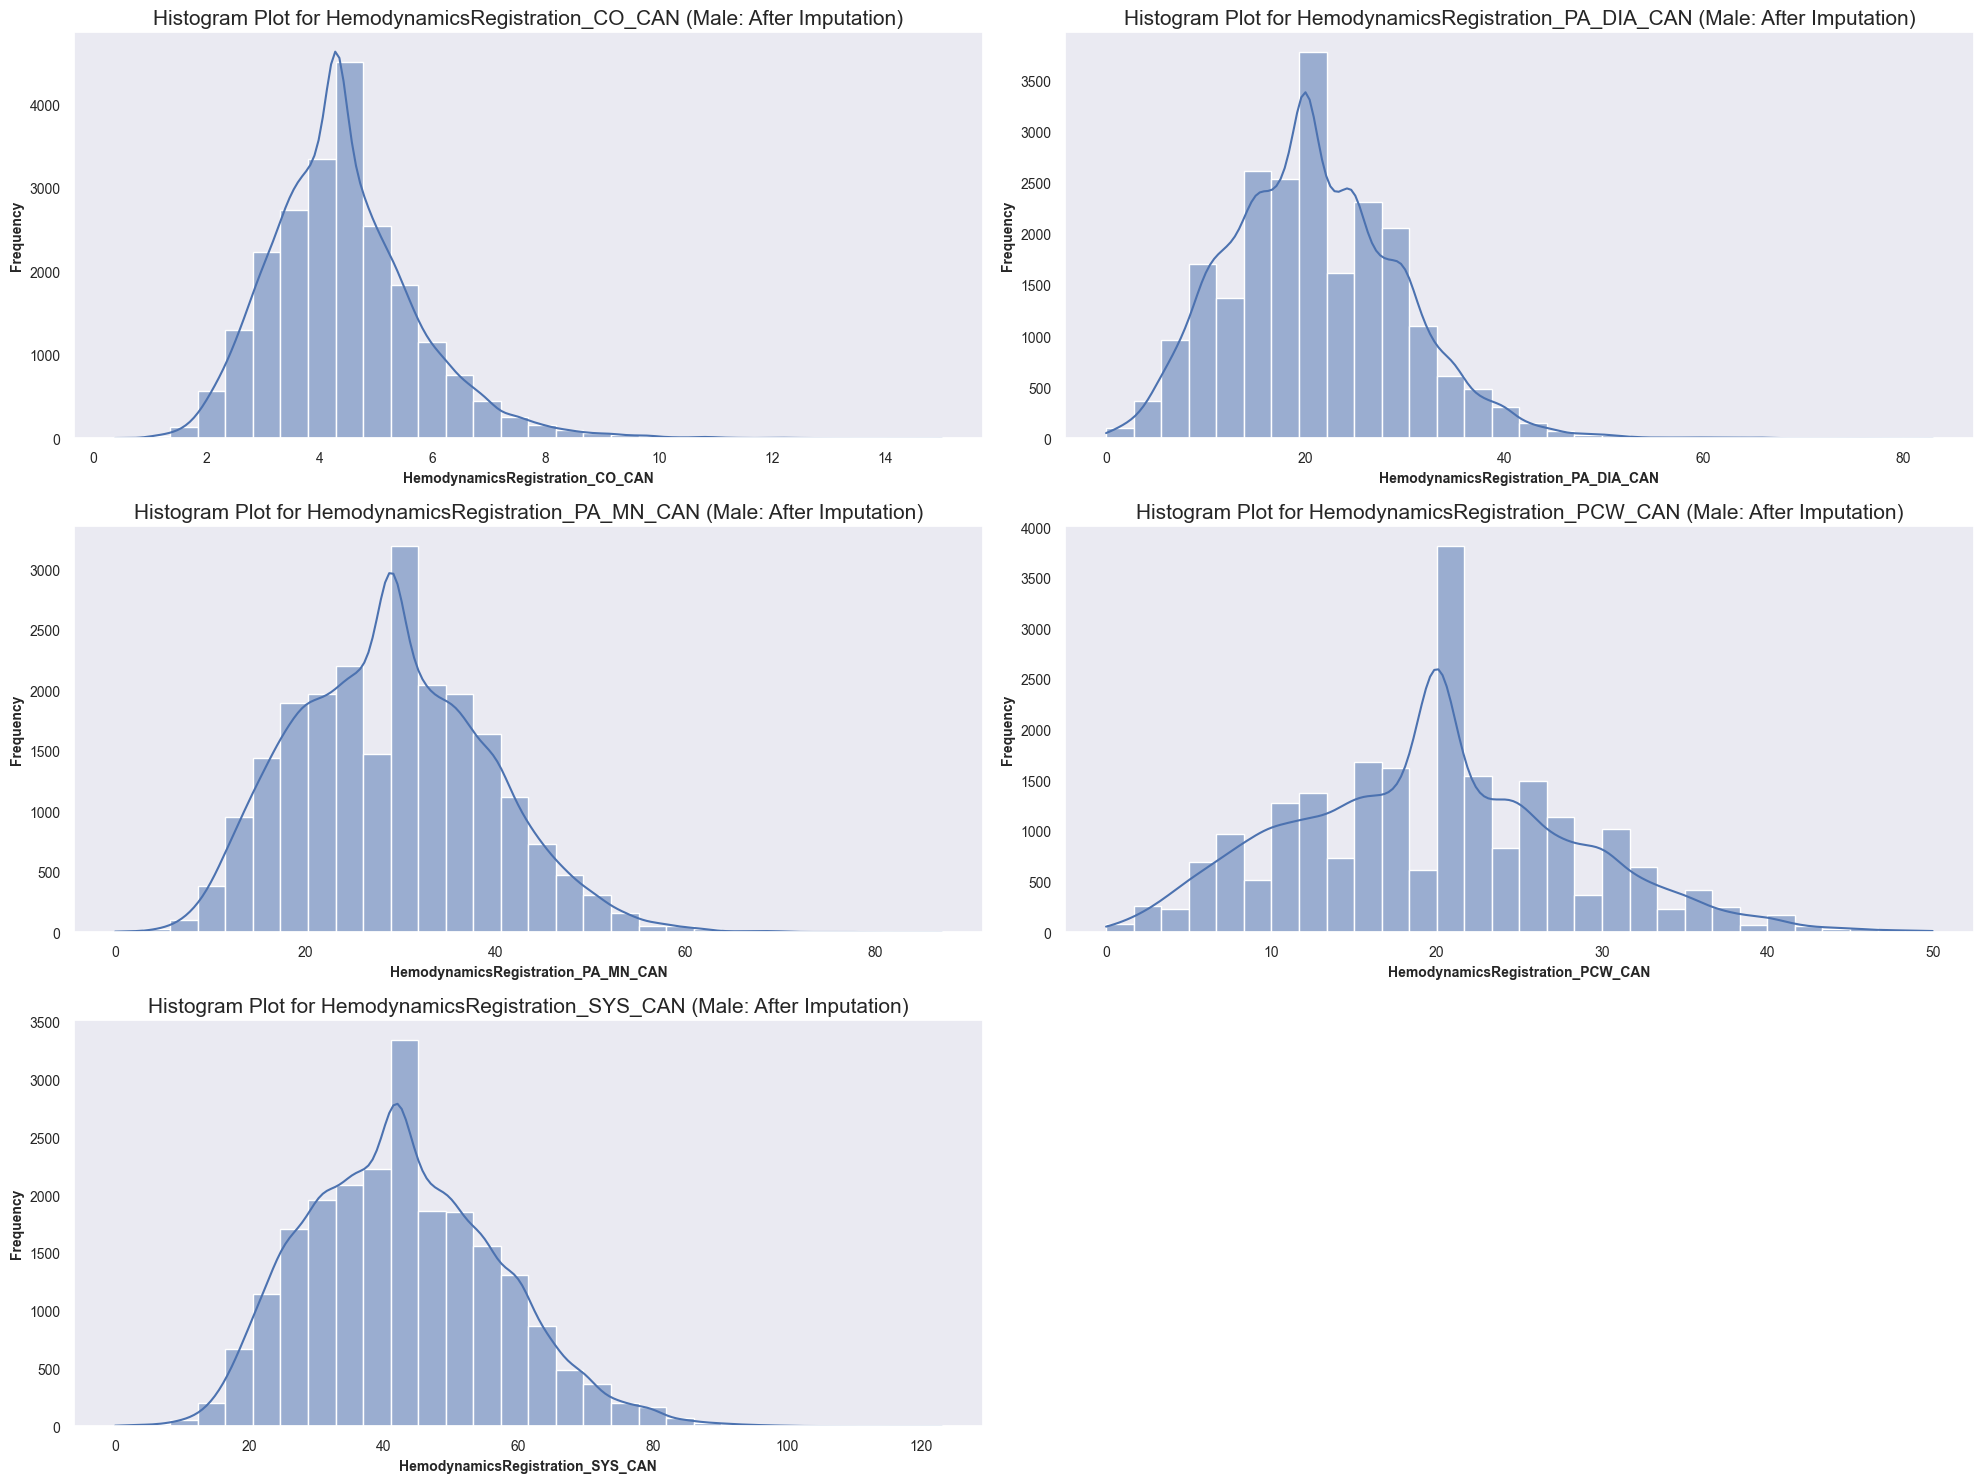

In [26]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male: After Imputation)')

#### Female

In [27]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsRegistration', cat=False)

                                      count       mean        std   min      25%    50%   75%    max
HemodynamicsRegistration_CO_CAN      7584.0   3.820094   1.228912  0.91   2.9700   3.68   4.5   15.0
HemodynamicsRegistration_PA_DIA_CAN  7723.0  19.802667   8.379385  0.00  14.0000  19.00  25.0   91.0
HemodynamicsRegistration_PA_MN_CAN   7672.0  27.739586   9.853808  4.00  20.9175  27.00  34.0   96.0
HemodynamicsRegistration_PCW_CAN     7313.0  18.210516   8.418194  0.00  12.0000  18.00  24.0   50.0
HemodynamicsRegistration_SYS_CAN     7727.0  40.676200  13.576105  0.00  31.0000  40.00  50.0  130.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        480
HemodynamicsRegistration_PA_DIA_CAN    341
HemodynamicsRegistration_PA_MN_CAN     392
HemodynamicsRegistration_PCW_CAN       751
HemodynamicsRegistration_SYS_CAN       337 



In [28]:
df_f[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.204048,-0.177482,-0.235581,-0.129799
HemodynamicsRegistration_PA_DIA_CAN,-0.204048,1.000000,0.884069,0.820830,0.789169
HemodynamicsRegistration_PA_MN_CAN,-0.177482,0.884069,1.000000,0.826852,0.909595
HemodynamicsRegistration_PCW_CAN,-0.235581,0.820830,0.826852,1.000000,0.751176
HemodynamicsRegistration_SYS_CAN,-0.129799,0.789169,0.909595,0.751176,1.000000


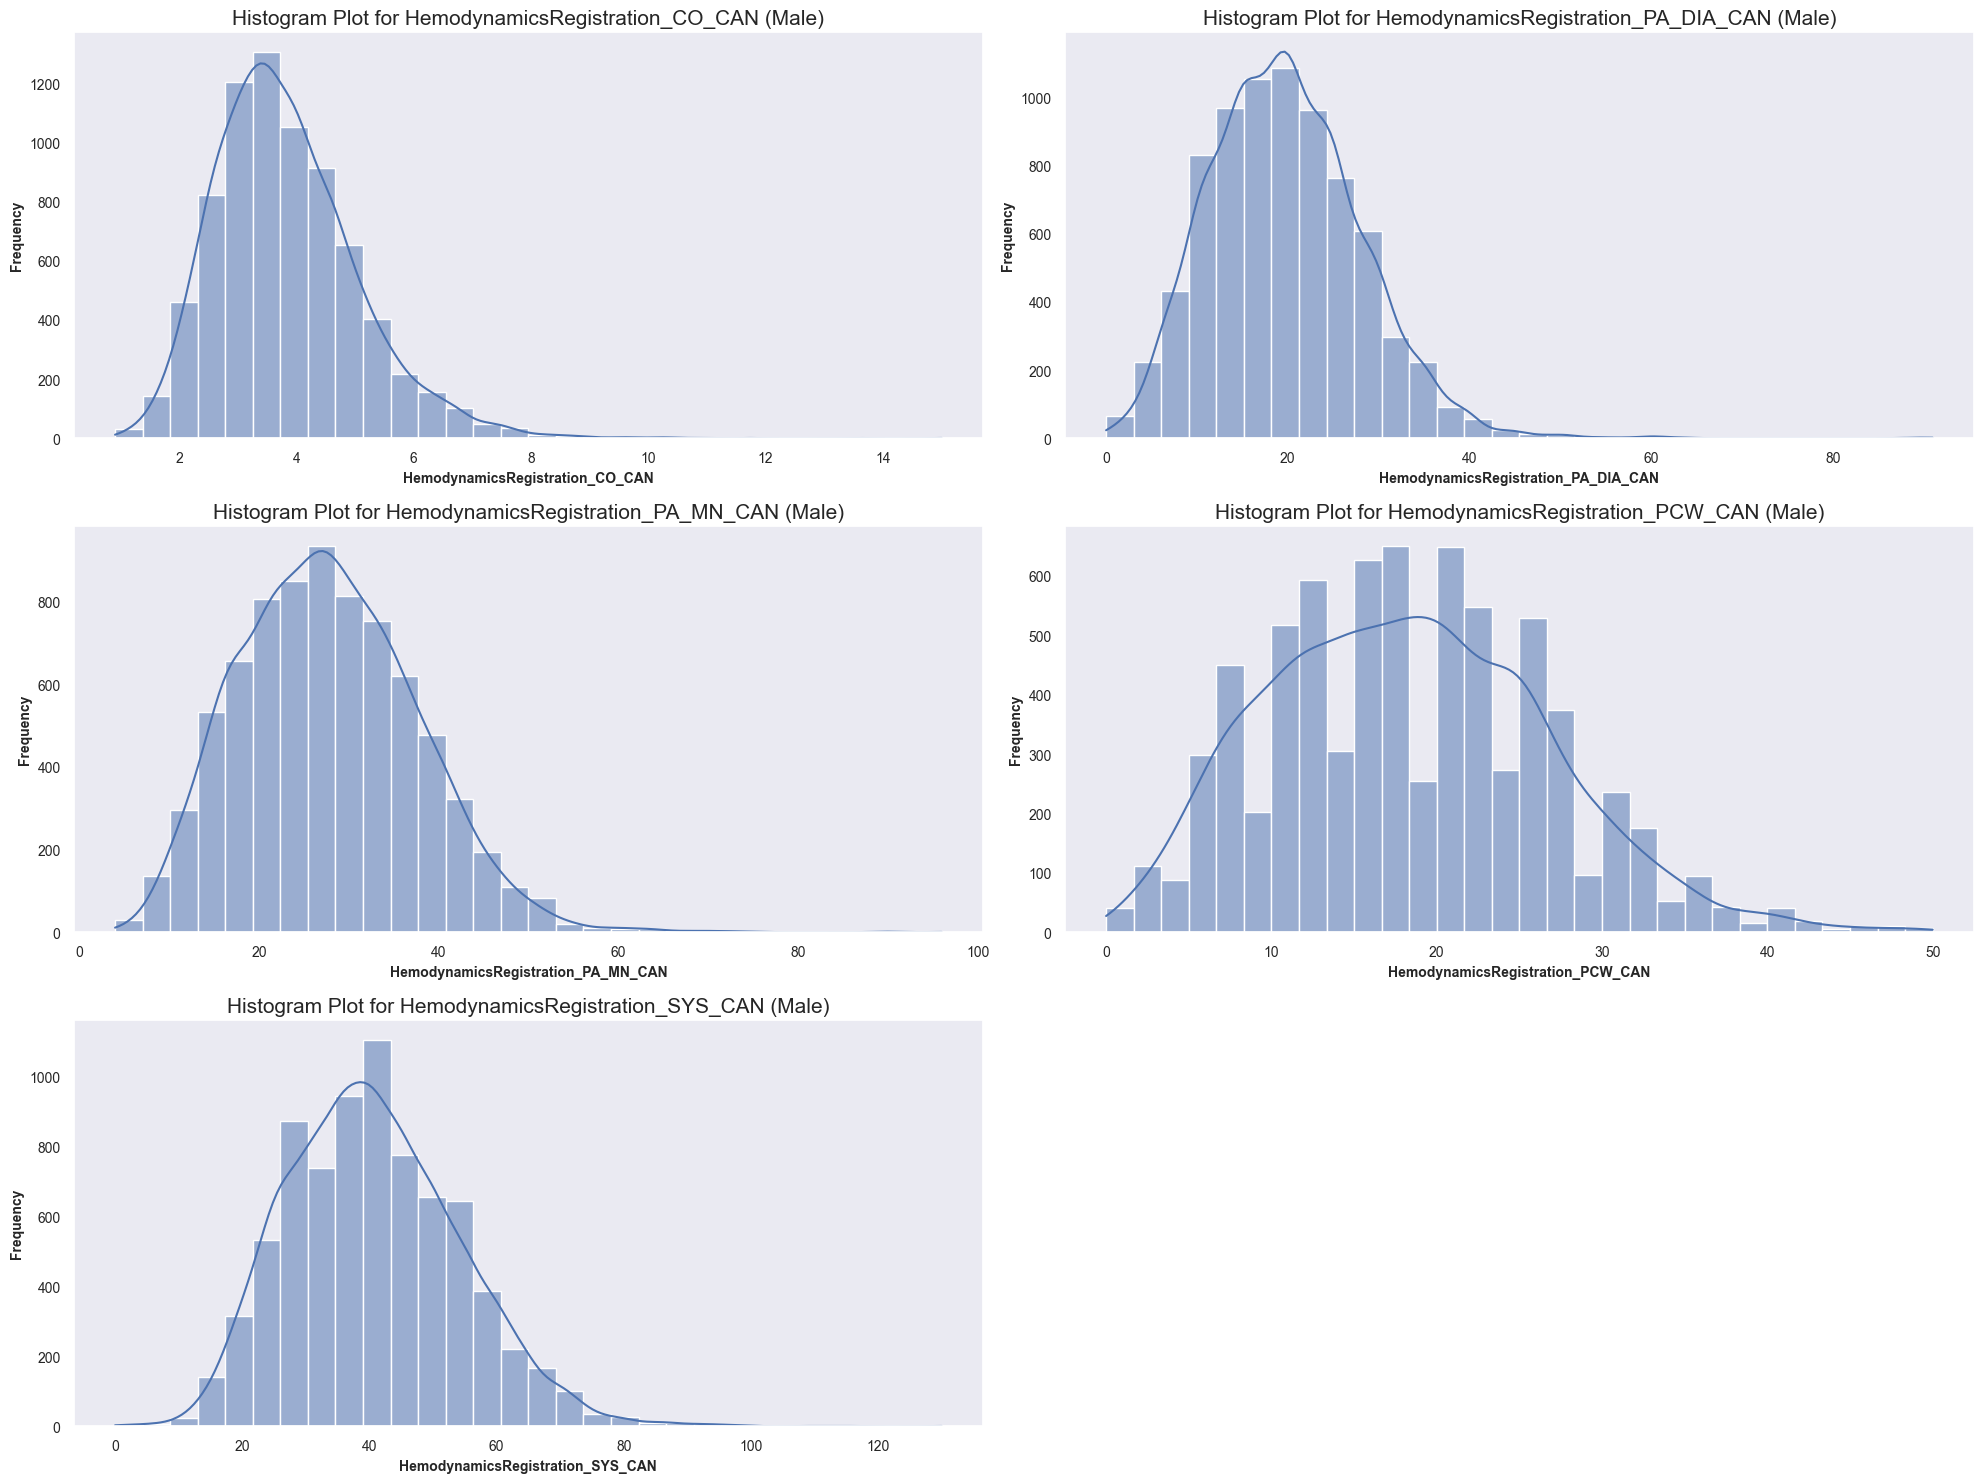

In [29]:
plot.plot_histogram(df_f, features, bins=30, txt='(Male)')

In [30]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=480, Known=7,584)
Mean survival:  (Unknown=1,490.4d, Known=1,420.0d)
Difference:     70.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2262
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0611 (Negligible)
95% CI:        [-0.0312, 0.1533]
Result: Likely Random Missingness (Effect size not significant)



In [31]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.025, p=0.03231 & Approx. Variance Explained=0.060%
Spearman r=-0.024, p=0.0392 & Approx. Variance Explained=0.056%



#### Median Imputation

In [32]:
# Median impute
df_f['HemodynamicsRegistration_CO_CAN'] = df_f['HemodynamicsRegistration_CO_CAN'].fillna(
    df_f['HemodynamicsRegistration_CO_CAN'].median()
)

In [33]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=341, Known=7,723)
Mean survival:  (Unknown=1,428.5d, Known=1,424.0d)
Difference:     4.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9485
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0039 (Negligible)
95% CI:        [-0.1046, 0.1123]
Result: Likely Random Missingness (Effect size not significant)



In [34]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.046, p=4.648e-05 & Approx. Variance Explained=0.215%
Spearman r=0.045, p=8.547e-05 & Approx. Variance Explained=0.200%



#### Median Imputation

In [35]:
# Median impute
df_f['HemodynamicsRegistration_PA_DIA_CAN'] = df_f['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [36]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=392, Known=7,672)
Mean survival:  (Unknown=1,566.9d, Known=1,416.9d)
Difference:     150.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0245
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     0.1301 (Negligible)
95% CI:        [0.0286, 0.2316]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Median Imputation

In [37]:
# Median impute
df_f['HemodynamicsRegistration_PA_MN_CAN'] = df_f['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [38]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=751, Known=7,313)
Mean survival:  (Unknown=1,455.1d, Known=1,421.0d)
Difference:     34.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.4569
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0295 (Negligible)
95% CI:        [-0.0456, 0.1046]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [39]:
# Median impute
df_f['HemodynamicsRegistration_PCW_CAN'] = df_f['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_f['HemodynamicsRegistration_PCW_CAN'].median()
)

In [40]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=337, Known=7,727)
Mean survival:  (Unknown=1,417.4d, Known=1,424.5d)
Difference:     -7.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9179
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0062 (Negligible)
95% CI:        [-0.1152, 0.1029]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [41]:
# Median impute
df_f['HemodynamicsRegistration_SYS_CAN'] = df_f['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_f['HemodynamicsRegistration_SYS_CAN'].median()
)

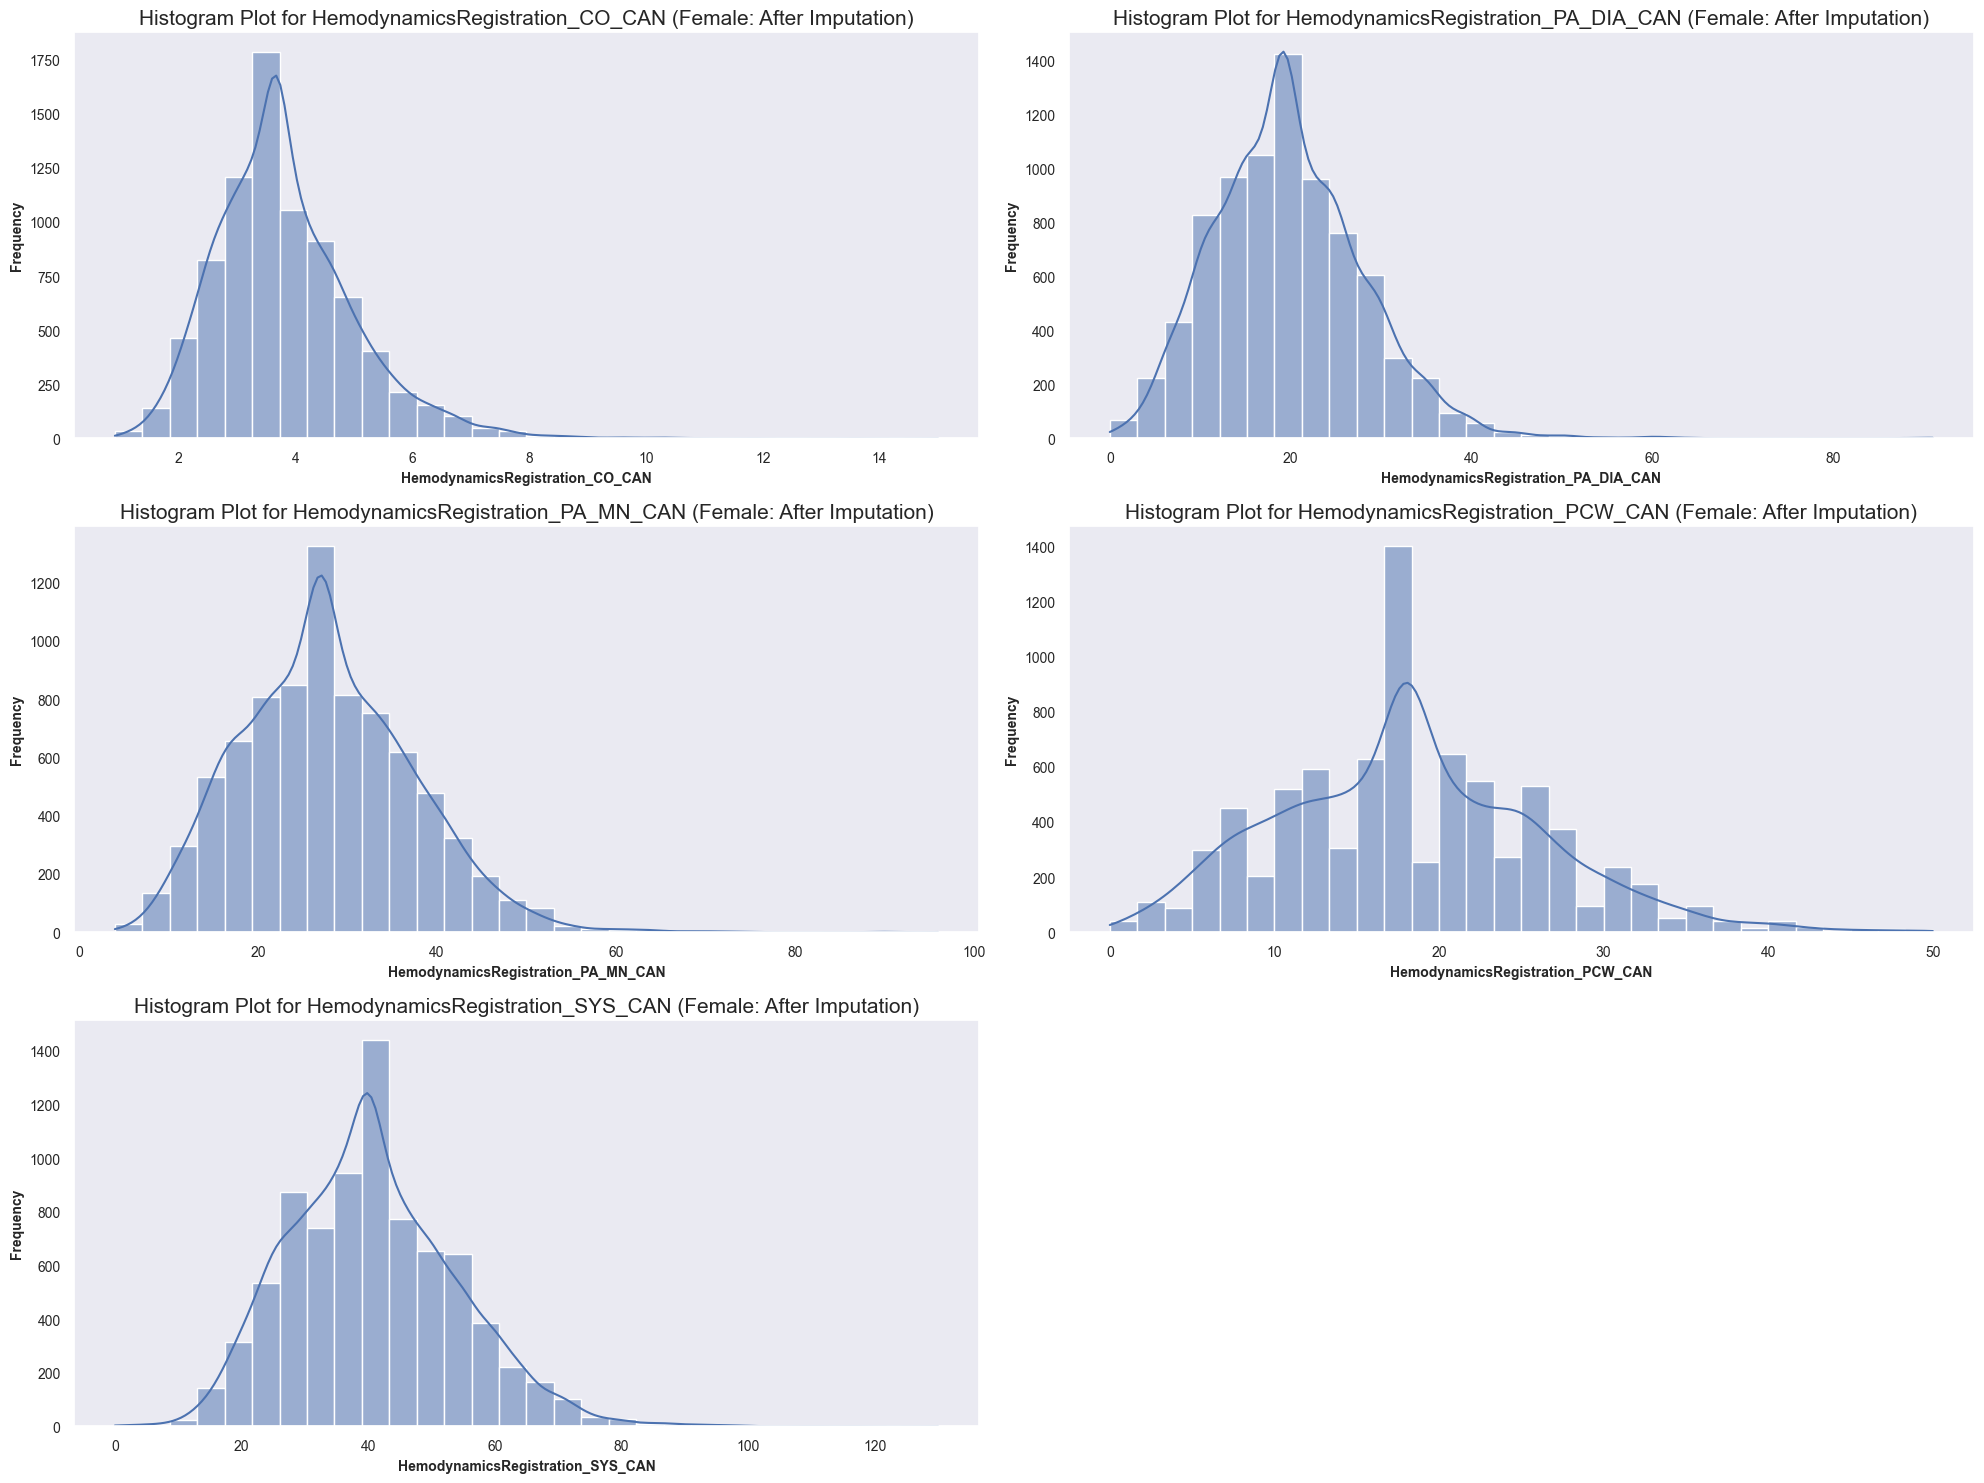

In [42]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female: After Imputation)')

### Hemodynamics Transplant

#### Male

In [43]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsTransplant', cat=False)
# add
total_features.extend(features)

                                     count       mean        std  min   25%    50%   75%    max
HemodynamicsTransplant_CO_CAN      21262.0   4.708002   1.461860  0.2   3.7   4.54   5.5   15.0
HemodynamicsTransplant_PA_DIA_CAN  21633.0  19.414261   8.582923  0.0  13.0  18.00  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN   21399.0  27.340928  10.050940  0.0  20.0  26.00  34.0  110.0
HemodynamicsTransplant_PCW_CAN     20622.0  18.151787   8.812605  0.0  11.0  17.00  24.0   50.0
HemodynamicsTransplant_SYS_CAN     21651.0  40.263868  14.058239  1.0  30.0  39.00  50.0  159.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN         974
HemodynamicsTransplant_PA_DIA_CAN     603
HemodynamicsTransplant_PA_MN_CAN      837
HemodynamicsTransplant_PCW_CAN       1614
HemodynamicsTransplant_SYS_CAN        585 



In [44]:
df_m[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.242740,-0.213030,-0.245328,-0.182213
HemodynamicsTransplant_PA_DIA_CAN,-0.242740,1.000000,0.904281,0.823678,0.794816
HemodynamicsTransplant_PA_MN_CAN,-0.213030,0.904281,1.000000,0.836996,0.918459
HemodynamicsTransplant_PCW_CAN,-0.245328,0.823678,0.836996,1.000000,0.767413
HemodynamicsTransplant_SYS_CAN,-0.182213,0.794816,0.918459,0.767413,1.000000


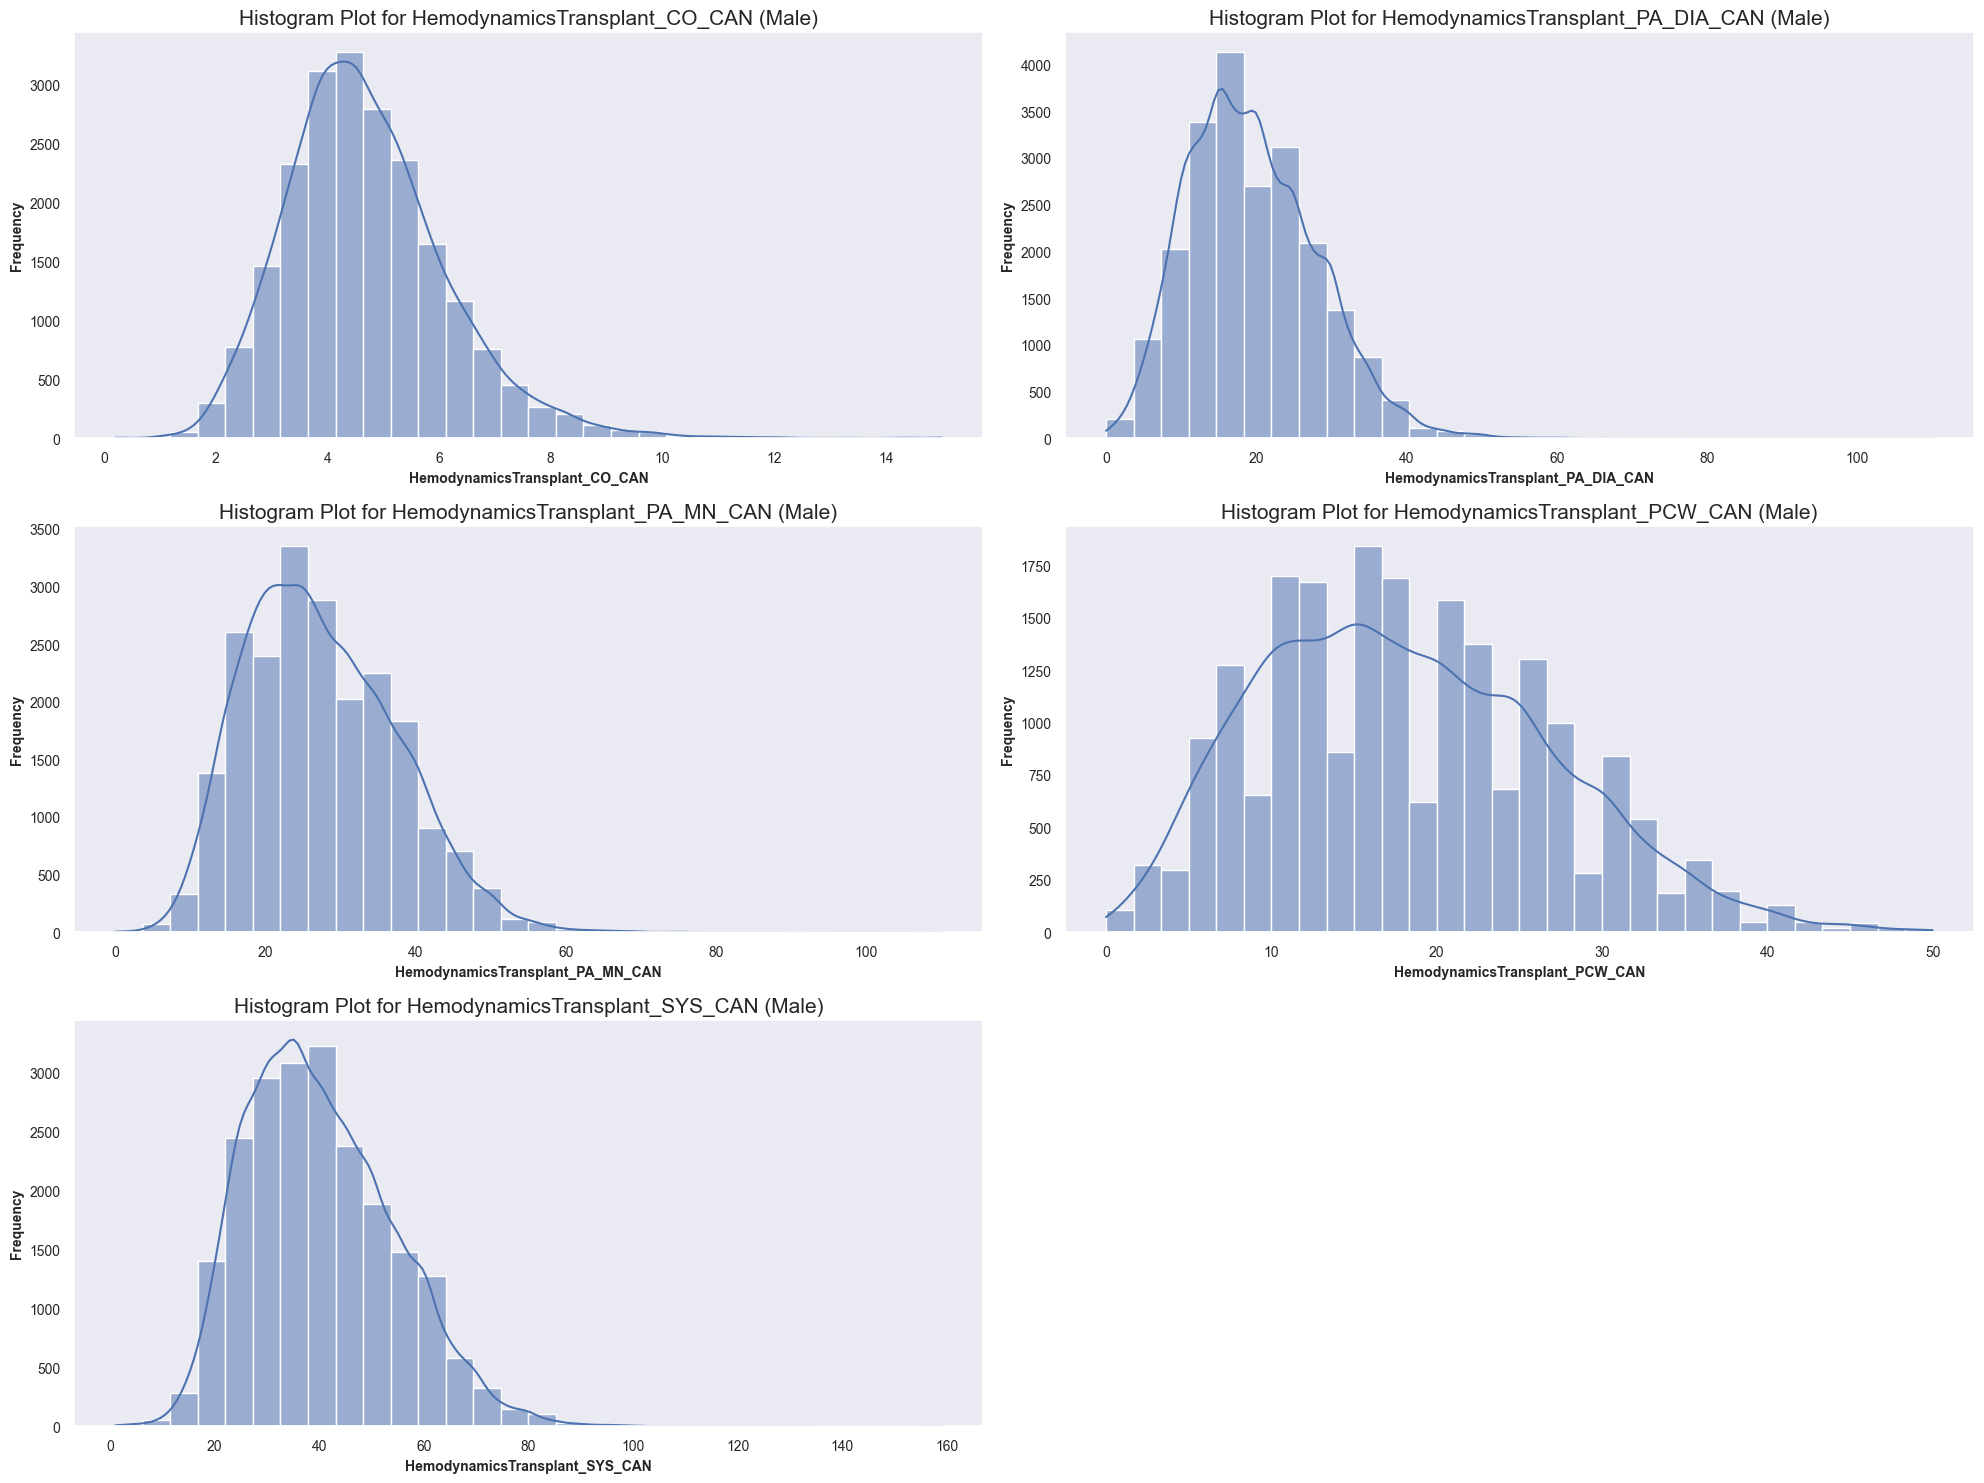

In [45]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [46]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=974, Known=21,262)
Mean survival:  (Unknown=1,282.7d, Known=1,443.8d)
Difference:     -161.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0001
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1393 (Negligible)
95% CI:        [-0.2035, -0.0750]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [47]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_CO_CAN ---
Pearson r=0.007, p=0.3145 & Approx. Variance Explained=0.005%
Spearman r=0.020, p=0.003902 & Approx. Variance Explained=0.039%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [48]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_CO_IsMissing'] = df_m['HemodynamicsTransplant_CO_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_CO_CAN'] = df_m['HemodynamicsTransplant_CO_CAN'].fillna(
    df_m['HemodynamicsTransplant_CO_CAN'].median()
)

In [49]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=603, Known=21,633)
Mean survival:  (Unknown=1,194.8d, Known=1,443.5d)
Difference:     -248.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2151 (Small)
95% CI:        [-0.2960, -0.1341]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [50]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=-0.008, p=0.2393 & Approx. Variance Explained=0.006%
Spearman r=-0.014, p=0.03799 & Approx. Variance Explained=0.020%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [51]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_DIA_IsMissing'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_DIA_CAN'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [52]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=837, Known=21,399)
Mean survival:  (Unknown=1,317.1d, Known=1,441.4d)
Difference:     -124.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0049
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1075 (Negligible)
95% CI:        [-0.1765, -0.0384]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [53]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.005, p=0.4218 & Approx. Variance Explained=0.003%
Spearman r=-0.003, p=0.6423 & Approx. Variance Explained=0.001%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [54]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_MN_IsMissing'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_MN_CAN'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [55]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=1,614, Known=20,622)
Mean survival:  (Unknown=1,276.3d, Known=1,449.3d)
Difference:     -173.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1496 (Negligible)
95% CI:        [-0.2003, -0.0990]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [56]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.013, p=0.05319 & Approx. Variance Explained=0.018%
Spearman r=0.003, p=0.693 & Approx. Variance Explained=0.001%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [57]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PCW_IsMissing'] = df_m['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PCW_CAN'] = df_m['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_m['HemodynamicsTransplant_PCW_CAN'].median()
)

In [58]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=585, Known=21,651)
Mean survival:  (Unknown=1,175.3d, Known=1,443.8d)
Difference:     -268.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2323 (Small)
95% CI:        [-0.3144, -0.1501]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [59]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.012, p=0.08823 & Approx. Variance Explained=0.013%
Spearman r=0.000, p=0.9924 & Approx. Variance Explained=0.000%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [60]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_SYS_IsMissing'] = df_m['HemodynamicsTransplant_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_SYS_CAN'] = df_m['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_m['HemodynamicsTransplant_SYS_CAN'].median()
)

#### Female

In [61]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsTransplant', cat=False)

                                    count       mean        std  min    25%   50%   75%    max
HemodynamicsTransplant_CO_CAN      7667.0   4.052243   1.327358  0.2   3.12   3.9   4.8   15.0
HemodynamicsTransplant_PA_DIA_CAN  7782.0  18.654562   8.203793  0.0  13.00  18.0  24.0   65.0
HemodynamicsTransplant_PA_MN_CAN   7717.0  26.460872   9.648381  0.0  19.00  26.0  33.0   88.0
HemodynamicsTransplant_PCW_CAN     7452.0  17.079301   8.375866  0.0  11.00  16.0  23.0   50.0
HemodynamicsTransplant_SYS_CAN     7788.0  38.855393  13.287188  0.0  29.00  38.0  47.0  127.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN        397
HemodynamicsTransplant_PA_DIA_CAN    282
HemodynamicsTransplant_PA_MN_CAN     347
HemodynamicsTransplant_PCW_CAN       612
HemodynamicsTransplant_SYS_CAN       276 



In [82]:
df_f[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.207203,-0.173323,-0.223600,-0.139277
HemodynamicsTransplant_PA_DIA_CAN,-0.207203,1.000000,0.883079,0.790826,0.777250
HemodynamicsTransplant_PA_MN_CAN,-0.173323,0.883079,1.000000,0.802820,0.906358
HemodynamicsTransplant_PCW_CAN,-0.223600,0.790826,0.802820,1.000000,0.727389
HemodynamicsTransplant_SYS_CAN,-0.139277,0.777250,0.906358,0.727389,1.000000


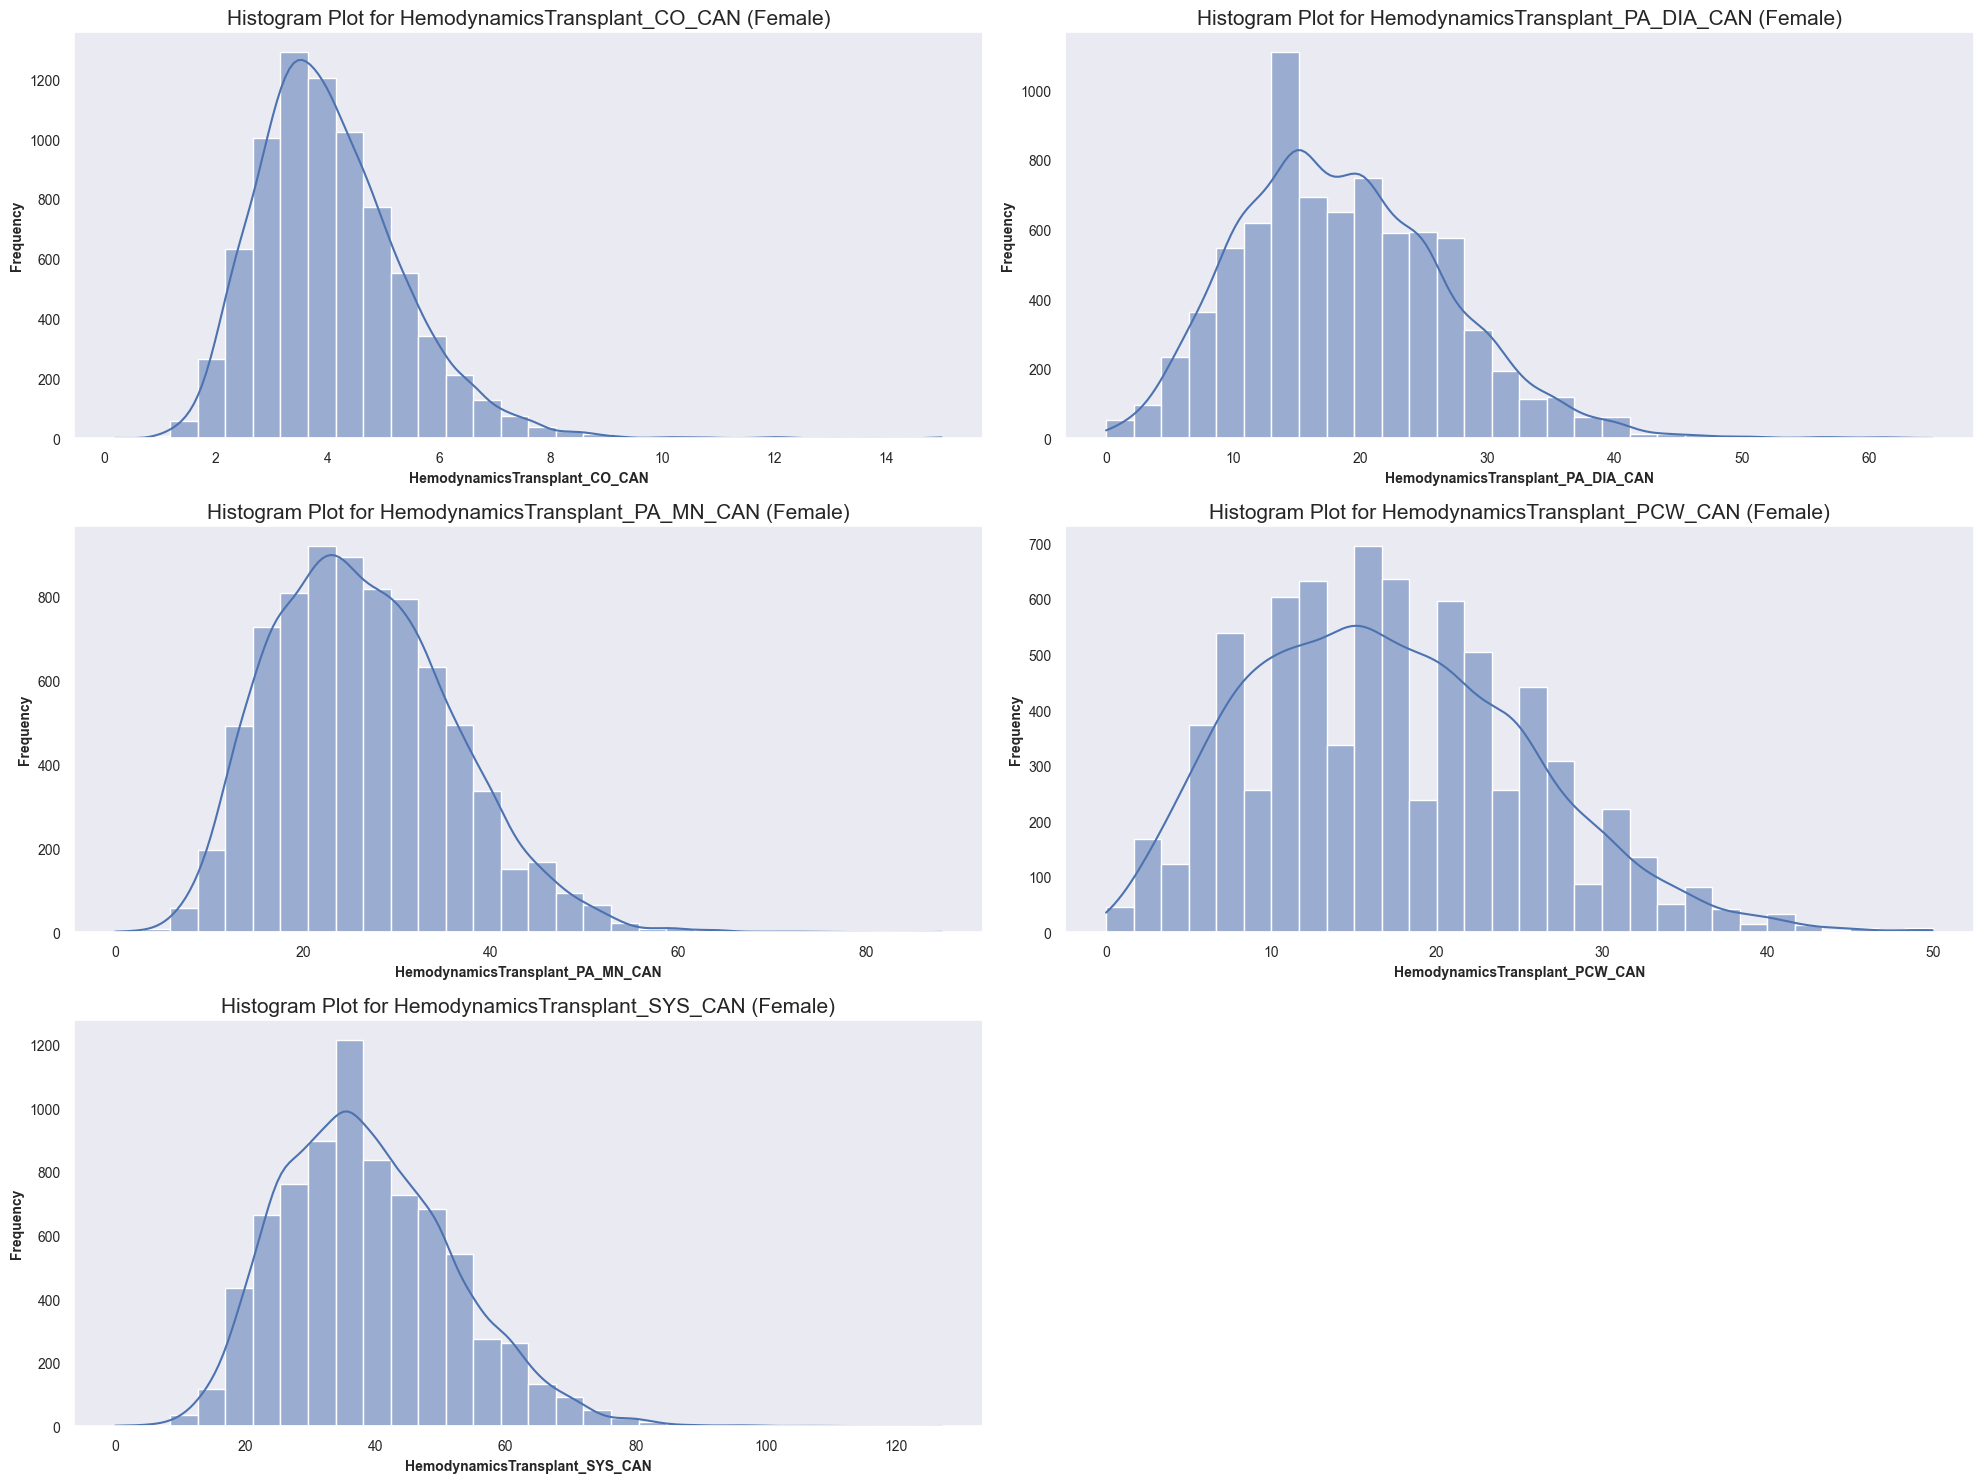

In [63]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [64]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=397, Known=7,667)
Mean survival:  (Unknown=1,384.8d, Known=1,426.2d)
Difference:     -41.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5181
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0360 (Negligible)
95% CI:        [-0.1368, 0.0649]
Result: Likely Random Missingness (Effect size not significant)



In [65]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_CO_CAN ---
Pearson r=-0.023, p=0.04261 & Approx. Variance Explained=0.054%
Spearman r=-0.018, p=0.1207 & Approx. Variance Explained=0.031%



#### Median Imputation

In [66]:
# Median impute
df_f['HemodynamicsTransplant_CO_CAN'] = df_f['HemodynamicsTransplant_CO_CAN'].fillna(
    df_f['HemodynamicsTransplant_CO_CAN'].median()
)

In [67]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=282, Known=7,782)
Mean survival:  (Unknown=1,385.3d, Known=1,425.6d)
Difference:     -40.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.6060
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0350 (Negligible)
95% CI:        [-0.1538, 0.0839]
Result: Likely Random Missingness (Effect size not significant)



In [68]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=0.014, p=0.2166 & Approx. Variance Explained=0.020%
Spearman r=0.002, p=0.8645 & Approx. Variance Explained=0.000%



#### Median Imputation

In [69]:
# Median impute
df_f['HemodynamicsTransplant_PA_DIA_CAN'] = df_f['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [70]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=347, Known=7,717)
Mean survival:  (Unknown=1,421.0d, Known=1,424.3d)
Difference:     -3.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9630
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0029 (Negligible)
95% CI:        [-0.1104, 0.1047]
Result: Likely Random Missingness (Effect size not significant)



In [71]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.030, p=0.007741 & Approx. Variance Explained=0.092%
Spearman r=0.016, p=0.149 & Approx. Variance Explained=0.027%



#### Median Imputation

In [72]:
# Median impute
df_f['HemodynamicsTransplant_PA_MN_CAN'] = df_f['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [73]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=612, Known=7,452)
Mean survival:  (Unknown=1,360.9d, Known=1,429.4d)
Difference:     -68.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1840
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0594 (Negligible)
95% CI:        [-0.1418, 0.0230]
Result: Likely Random Missingness (Effect size not significant)



In [74]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.021, p=0.06621 & Approx. Variance Explained=0.045%
Spearman r=0.014, p=0.2341 & Approx. Variance Explained=0.019%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [75]:
# impute: median and use new feature for NANS
df_f['HemodynamicsTransplant_PCW_IsMissing'] = df_f['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_f['HemodynamicsTransplant_PCW_CAN'] = df_f['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_f['HemodynamicsTransplant_PCW_CAN'].median()
)

In [76]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=276, Known=7,788)
Mean survival:  (Unknown=1,376.3d, Known=1,425.9d)
Difference:     -49.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5305
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0430 (Negligible)
95% CI:        [-0.1630, 0.0771]
Result: Likely Random Missingness (Effect size not significant)



In [77]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.032, p=0.004877 & Approx. Variance Explained=0.102%
Spearman r=0.019, p=0.09481 & Approx. Variance Explained=0.036%



#### Median Imputation

In [78]:
# Median impute
df_f['HemodynamicsTransplant_SYS_CAN'] = df_f['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_f['HemodynamicsTransplant_SYS_CAN'].median()
)

#### All features for Hemodynamics

In [79]:
# PCA - feature engineering
df_f = apply_pca_feature_engineering(df_f, total_features, "hemodynamics")
df_m = apply_pca_feature_engineering(df_m, total_features, "hemodynamics")

[hemodynamics] Retained 5 components (93.23% variance explained)
[hemodynamics] Retained 5 components (93.46% variance explained)


In [84]:
pd.set_option('display.max_columns', None)
df_f.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Weight_kg_Registrsation_CAN,Height_cm_Registration_CAN,BMI_Listing_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,LifeSupportRegistration_ECMO_CAN,LifeSupportRegistration_IABP_CAN,LifeSupportInhaled_CAN,InotropesIVRegistration_CAN,LifeSupportRegistration_PGE_CAN,LifeSupportMechanismRegistration_OTHER_CAN,VentricularDeviceTypeRegistration_CAN,VentricularDeviceBrandRegistration_CAN,FunctionalStatusRegistration_CAN,PrimaryPaymentRegistration_CAN,DiagnosisAtListing_CAN,DiabetesType_CAN,DialysisTypeRegistration_CAN,CerebroVascularDisease_CAN,PreviousMalignancy_CAN,CreatinineRegistration_CAN,DefibrillatorImplantRegistration_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_CO_CAN,InotropesVasodilatorsRegistration_SYS_CAN,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_MN_CAN,InotropesVasodilatorsRegistration_PCW_CAN,InotropesVasodilatorsRegistration_CO_CAN,CigaretteUse_CAN,CigaretteAbstinence_CAN,PriorCardiacSurgery_CAN,PriorCardiacSurgeryType_CAN,InitialWaitingListStatusCode_CAN,ReceivedDeceasedDonorTramsplant_CAN,TotalDayWaitList_CAN,StatusAtTransplant_CAN,Age_Listing_CAN,LifeSupportRegistration_CAN,Ethnicity_CAN,Height_cm_Listing_CAN,Weight_kg_Listing_CAN,BMI_Listing_CALC_CAN,Height_cm_Removal_CAN,Weight_kg_Removal_CAN,BMI_Removal_CAN,VentilatorRegistration_CAN,TransplantRegion_CAN,WorkIncomeRegistration_CAN,AntigenBW4_CAN,AntigenBW6_CAN,AntigenC1_CAN,AntigenC2_CAN,AntigenDR51_CAN,AntigenDR51_2_CAN,AntigenDR52_CAN,AntigenDR52_2_CAN,AntigenDR53_CAN,AntigenDR53_2_CAN,AntigenDQ1_CAN,AntigenDQ2_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,PrimaryPaymentTransplant_CAN,LifeSupportTransplant_ECMO_CAN,ResidencyStateTransplant_CAN,WorkIncomeTransplant_CAN,LifeSupportTransplant_PGE_CAN,CreatinineTransplant_CAN,DialysisBetweenRegistrationTransplant_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN,LifeSupportTransplant_IABP_CAN,InfectionTherapyIV_CAN,InotropesIVTransplant_CAN,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_MN_CAN,InotropesVasodilatorsTransplant_PCW_CAN,InotropesVasodilatorsTransplant_SYS_CAN,LifeSupportMechanismTransplant_OTHER_CAN,PriorLungSurgeryAfterRegistration_CAN,SteroidsUse_CAN,TotalBilirubinTransplant_CAN,TransfusionAfterRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandTransplant_CAN,VentilatorySupport_CAN,VentilatorTransplant_CAN,LifeSupportInhaledTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,Hepatitis_B_CoreAntibody_CAN,SurfaceAntigenHEP_B_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,CMVStatus_Transplant_CAN,HIV_SeroStatusTransplant_CAN,HEP_C_SerostatusStatus_CAN,EpsteinBarrSeroStatusTransplant_CAN,HIV_NAT_PreTransplant_CAN,HCV_NAT_PreTranspant_CAN,HBV_NAT_Result_CAN,LifeSupportInhaledRegistration_CAN,PreviousTransplantSameOrgan_CAN,PreviousTransplantAnyOrgan_CAN,AntigenRA1_CAN,AntigenRA2_CAN,AntigenRB1_CAN,AntigenRB2_CAN,AntigenRDR1_CAN,AntigenRDR2_CAN,MalignancyBetweenRegistrationTransplant_CAN,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,TransplantType_CAN,Age_CAN,PrimaryDiagnosisType_CAN,DialysisPriorRegistration_CAN,LifeSupportTransplant_CAN,PriorCardiacSurgeryListAndTransplant_CAN,Malignancy_CAN,Height_cm_CAN,Weight_kg_CAN,BMI_Calc_CAN,DistanceFromDonorHospitaltoTXCenter_CAN,VentilatorySupportAfterRegistration_CAN,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel,HemodynamicsTransplant_PCW_IsMissing,PC1_hemodynamics,PC2_hemodynamics,PC3_hemodynamics,PC4_hemodynamics,PC5_hemodynamics,PC1_hemo

## Functional Status Registration

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusRegistration_CAN', cat=True)

In [ ]:
plot_histogram(df_m, features[0], bins=30, txt='Male', KDE=False)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusRegistration_IsMissing'] = df_m [features[0]].isna().astype(int)
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].mode()[0]
)
# change datatype
df_m[features[0]] = df_m[features[0]].astype('category')
# sanity check
df_m.FunctionalStatusRegistration_IsMissing.sum()

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusRegistration', cat=False)

In [ ]:
plot_histogram(df_f, features[0], bins=30, txt='Female', KDE=False)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [ ]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusRegistration_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusRegistration_IsMissing.sum()

## Functional Status Transplant

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusTransplant', cat=True)

In [ ]:
plot_histogram(df_m, features[0], bins=30, txt='Male', KDE=False)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [ ]:
# impute: mode and use new feature for NANS
df_m['FunctionalStatusTransplant_IsMissing'] = df_m[features[0]].isna().astype(int)
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].mode()[0])
# change datatype
df_m[features[0]] = df_m[features[0]].astype('category')
# sanity check
df_m.FunctionalStatusTransplant_IsMissing.sum()

In [ ]:
df_m[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusTransplant', cat=False)

In [ ]:
plot_histogram(df_f, features[0], bins=30, txt='Female', KDE=False)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [ ]:
# impute: mode and use new feature for NANS
df_f['FunctionalStatusTransplant_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusTransplant_IsMissing.sum()

In [ ]:
df_f[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

## Creatinine Registration
#### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'CreatinineRegistration_CAN', cat=False)

In [ ]:
plot_histogram(df_m, features[0], bins=30, txt='Male')

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

In [ ]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

#### Female

In [ ]:
features = u.get_feature_info(df_f, 'CreatinineRegistration_CAN', cat=False)

In [ ]:
plot_histogram(df_f, features[0], bins=30, txt='Female')

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

In [ ]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

#### Log Transform

In [ ]:
# Log Transform
df_m['CreatinineRegistration_Log'] = np.log1p(df_m[features[0]])
# female
df_f['CreatinineRegistration_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

In [ ]:
plot_histogram(df_m, 'CreatinineRegistration_Log', txt='Male: Creatinine Registration Log', bins=30)

In [ ]:
plot_histogram(df_f, 'CreatinineRegistration_Log', txt='Female: Creatinine Registration Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['CreatinineRegistration_Log_IsMissing'] = df_m.CreatinineRegistration_Log.isna().astype(int)
# female
df_f['CreatinineRegistration_Log_IsMissing'] = df_f.CreatinineRegistration_Log.isna().astype(int)
# median
df_m['CreatinineRegistration_Log'] = df_m.CreatinineRegistration_Log.fillna(df_m.CreatinineRegistration_Log.median())
# female
df_f['CreatinineRegistration_Log'] = df_f.CreatinineRegistration_Log.fillna(df_f.CreatinineRegistration_Log.median())
# sanity check
df_m['CreatinineRegistration_Log_IsMissing'].sum(), df_f['CreatinineRegistration_Log_IsMissing'].sum()

## Creatinine Transplant

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'CreatinineTransplant_CAN', cat=False)

In [ ]:
plot_histogram(df_m, features[0], bins=30, txt='Male')

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

In [ ]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Female')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'CreatinineTransplant_CAN', cat=False)

In [ ]:
plot_histogram(df_f, features[0], bins=30, txt='Female')

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

In [ ]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

#### Log Transform

In [ ]:
# Log Transform
df_m['CreatinineTransplant_Log'] = np.log1p(df_m[features[0]])
# female
df_f['CreatinineTransplant_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

In [ ]:
plot_histogram(df_m, 'CreatinineTransplant_Log', txt='Male: Creatinine Transplant Log', bins=30)

In [ ]:
plot_histogram(df_f, 'CreatinineTransplant_Log', txt='Female: Creatinine Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['CreatinineTransplant_Log_IsMissing'] = df_m.CreatinineTransplant_Log.isna().astype(int)
# female
df_f['CreatinineTransplant_Log_IsMissing'] = df_f.CreatinineTransplant_Log.isna().astype(int)
# median
df_m['CreatinineTransplant_Log'] = df_m.CreatinineTransplant_Log.fillna(df_m.CreatinineTransplant_Log.median())
# female
df_f['CreatinineTransplant_Log'] = df_f.CreatinineTransplant_Log.fillna(df_f.CreatinineTransplant_Log.median())
# sanity check
df_m['CreatinineTransplant_Log_IsMissing'].sum(), df_f['CreatinineTransplant_Log_IsMissing'].sum()

In [ ]:
# correlation
df_m[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

In [ ]:
# correlation
df_f[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

In [ ]:
# info
features = u.get_feature_info(df_m, r'^Creatinine.*_Log$' , cat=False) 

In [ ]:
df_m[features].corr()

In [ ]:
df_f[features].corr()

#### PCA

In [ ]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "creatinine_log")
df_f = apply_pca_feature_engineering(df_f, features, "creatinine_log")

## TotalBilirubin Transplant
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'TotalBilirubinTransplant', cat=False) 

In [ ]:
plot_histogram(df_m, features[0], txt='Male: Total Bilirubin Transplant', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

In [ ]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'TotalBilirubinTransplant', cat=False) 

In [ ]:
plot_histogram(df_f, features[0], txt='Female: Total Bilirubin Transplant', bins=30)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

In [ ]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

#### Log Transform

In [ ]:
# Log Transform
df_m['TotalBilirubinTransplant_Log'] = np.log1p(df_m[features[0]])
# female
df_f['TotalBilirubinTransplant_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

In [ ]:
plot_histogram(df_m, 'TotalBilirubinTransplant_Log', txt='Male: Total Bilirubin Transplant Log', bins=30)

In [ ]:
plot_histogram(df_f, 'TotalBilirubinTransplant_Log', txt='Female: Total Bilirubin Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['TotalBilirubinTransplant_Log_IsMissing'] = df_m.TotalBilirubinTransplant_Log.isna().astype(int)
# female
df_f['TotalBilirubinTransplant_Log_IsMissing'] = df_f.TotalBilirubinTransplant_Log.isna().astype(int)
# median
df_m['TotalBilirubinTransplant_Log'] = df_m.TotalBilirubinTransplant_Log.fillna(df_m.TotalBilirubinTransplant_Log.median())
# female
df_f['TotalBilirubinTransplant_Log'] = df_f.TotalBilirubinTransplant_Log.fillna(df_f.TotalBilirubinTransplant_Log.median())
# sanity check
df_m['TotalBilirubinTransplant_Log_IsMissing'].sum(), df_f['TotalBilirubinTransplant_Log_IsMissing'].sum()

## BMI
$ \text{Metric System:} \space \text{Weight(kg)} \space / \space \text{Height(m)}^2$

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

In [ ]:
# check BMI unrealistic data
df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

In [ ]:
# get index and recalc BMI_Listing_CAN
idx = df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [ ]:
# sanity check
df_m.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

In [ ]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

In [ ]:
df_m[features].corr()

In [ ]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_CAN'] /
    (df_m.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [ ]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [ ]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [ ]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_m.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [ ]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

In [ ]:
# check BMI unrealistic data
df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

In [ ]:
# get index and recalc BMI_Listing_CAN
idx = df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)
# sanity check
df_f.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

In [ ]:
df_f[features].corr()

In [ ]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_CAN'] /
    (df_f.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [ ]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [ ]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [ ]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_f.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [ ]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

### Median

In [ ]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

In [ ]:
df_m[features].corr()

In [ ]:
df_f[features].corr()

#### PCA

In [ ]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "BMI")
df_f = apply_pca_feature_engineering(df_f, features, "BMI")

## Weight (Kg)

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Weight', cat=False) 

In [ ]:
df_m[features].corr()

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'Weight', cat=False) 

In [ ]:
df_f[features].corr()

### Median

In [ ]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

#### PCA

In [ ]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "weight")
df_f = apply_pca_feature_engineering(df_f, features, "weight")

## Height

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Height', cat=False)

In [ ]:
df_m[features].corr()

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'Height', cat=False) 

In [ ]:
df_f[features].corr()

### Median

In [ ]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

#### PCA

In [ ]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "height")
df_f = apply_pca_feature_engineering(df_f, features, "height")

## Age

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Age', cat=False) 

In [ ]:
df_m[features].corr()

### Female

In [ ]:
df_f[features].corr()

#### PCA

In [ ]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "age")
df_f = apply_pca_feature_engineering(df_f, features, "age")

## NaNs

In [ ]:
# check for NaNs
df_m.isna().any().any(), df_f.isna().any().any()

## Write to Disk

In [ ]:
# save data: heart dataset
u.write_to_file(df_f, 'Candidate_Female_Heart',path='../Data/', format='parquet')
u.write_to_file(df_m, 'Candidate_Male_Heart',path='../Data/', format='parquet')